In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [2]:
#Create a path to where your data is stored.
path = r'/Users/april/Machine Learning'

In [3]:
#Create a path to where your data is stored.
path2 = r'/Users/april/Machine Learning/Datasets'

In [4]:
# Export weather data
X = pd.read_csv(os.path.join(path, 'weather_clean.csv'), index_col =False)

In [5]:
#Read in the pleasant weather data.
pleasantweather = pd.read_csv(os.path.join(path2, 'Supervised','Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))
pleasantweather

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22945,20221027,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
22946,20221028,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
22947,20221029,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
22948,20221030,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Data Wrangling

In [6]:
# Reduce observations dataset to 2010's

dfdecade = X[(X['DATE'].astype(str).str[:4] >= '2010') & (X['DATE'].astype(str).str[:4] <= '2019')]
dfdecade

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,BELGRADE_humidity,BELGRADE_pressure,BELGRADE_global_radiation,BELGRADE_precipitation,BELGRADE_sunshine,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,BUDAPEST_cloud_cover,BUDAPEST_humidity,BUDAPEST_pressure,BUDAPEST_global_radiation,BUDAPEST_precipitation,BUDAPEST_sunshine,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max,DEBILT_cloud_cover,DEBILT_humidity,DEBILT_pressure,DEBILT_global_radiation,DEBILT_precipitation,DEBILT_sunshine,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max,DUSSELDORF_cloud_cover,DUSSELDORF_humidity,DUSSELDORF_pressure,DUSSELDORF_global_radiation,DUSSELDORF_precipitation,DUSSELDORF_sunshine,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max,HEATHROW_cloud_cover,HEATHROW_humidity,HEATHROW_pressure,HEATHROW_global_radiation,HEATHROW_precipitation,HEATHROW_sunshine,HEATHROW_temp_mean,HEATHROW_temp_min,HEATHROW_temp_max,KASSEL_cloud_cover,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max,LJUBLJANA_cloud_cover,LJUBLJANA_humidity,LJUBLJANA_pressure,LJUBLJANA_global_radiation,LJUBLJANA_precipitation,LJUBLJANA_sunshine,LJUBLJANA_temp_mean,LJUBLJANA_temp_min,LJUBLJANA_temp_max,MAASTRICHT_cloud_cover,MAASTRICHT_humidity,MAASTRICHT_pressure,MAASTRICHT_global_radiation,MAASTRICHT_precipitation,MAASTRICHT_sunshine,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max,MADRID_cloud_cover,MADRID_humidity,MADRID_pressure,MADRID_global_radiation,MADRID_precipitation,MADRID_sunshine,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max,MUNCHENB_cloud_cover,MUNCHENB_humidity,MUNCHENB_pressure,MUNCHENB_global_radiation,MUNCHENB_precipitation,MUNCHENB_sunshine,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max,OSLO_cloud_cover,OSLO_humidity,OSLO_pressure,OSLO_global_radiation,OSLO_precipitation,OSLO_sunshine,OSLO_temp_mean,OSLO_temp_min,OSLO_temp_max,SONNBLICK_cloud_cover,SONNBLICK_humidity,SONNBLICK_pressure,SONNBLICK_global_radiation,SONNBLICK_precipitation,SONNBLICK_sunshine,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,STOCKHOLM_cloud_cover,STOCKHOLM_humidity,STOCKHOLM_pressure,STOCKHOLM_global_radiation,STOCKHOLM_precipitation,STOCKHOLM_sunshine,STOCKHOLM_temp_mean,STOCKHOLM_temp_min,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
18263,20100101,-1.599964,1.076130,1.548792,-3.288021,-1.251420,0.676766,-1.065304,-1.017527,-0.998933,-1.177051,0.652846,1.190400,-3.430229,-1.000382,4.786143,-0.593919,-0.313229,-0.015684,-0.400906,0.733328,-0.010098,-0.005876,-1.267237,-0.344984,-1.170378,-0.793315,-0.584533,-0.860946,-0.673053,-0.354910,-1.293622,-0.860780,-0.498787,-0.048655,-1.838979,-2.102599,-1.822356,1.232526,1.143615,-1.928262,-1.157575,-0.449820,-1.014908,-1.740492,-1.529682,-1.936556,-1.623672,-0.012023,-0.936526,-0.781415,-0.436400,0.538458,-1.678883,-1.466534,-1.541696,1.205492,1.463623,-2.153687,-1.267817,0.017139,-1.074723,-1.733389,-1.402013,-1.872466,1.205492,1.632150,-3.214028,-1.286850,0.088387,-1.149211,-0.462649,-0.117925,-0.826749,0.703568,0.982870,-1.635203,-1.163075,-0.451686,-1.057726,-1.822435,-2.053337,-1.960145,0.484733,1.322744,-0.915829,-1.496755,-0.289516,-1.184150,-1.257862,-1.001951,-1.415676,0.731180,1.183399,-0.486335,-1.244144,0.292068,-1.098059,-0.743302,-0.644217,-0.951273,0.682401,0.165114,-0.049848,-1.067870,0.045478,-1.018677,-1.715566,-1.537028,-1.641071,-0.428835,0.274900,-0.486335,-1.038620,0.116782,0.199980,-0.680084,-0.599621,-0.751687,0.291952,0.165114,-0.174574,-1.008328,-0.223582,-0.712731,-1.859060,-1.759336,-1.947133,-2.897272,-0.363113,-0.199725,-0.829990,-0.490810,0.762612,-2.711082,-2.596636,-2.448957
18264,20100102

In [7]:
# Reduce pleasantweather dataset to 2010's

pleasantweather_decade = pleasantweather[(pleasantweather['DATE'].astype(str).str[:4] >= '2010') & (pleasantweather['DATE'].astype(str).str[:4] <= '2019')]
pleasantweather_decade

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
18263,20100101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18264,20100102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18265,20100103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18266,20100104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18267,20100105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21910,20191227,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21911,20191228,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21912,20191229,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21913,20191230,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
# Drop columns that end with wind_speed and snow_depth from the dataset

columns_to_drop = dfdecade.filter(regex='(_wind_speed|_snow_depth)$').columns
columns_to_drop

Index([], dtype='object')

In [10]:
dfdecade = dfdecade.drop(columns=columns_to_drop)


In [11]:
# Drop unnecessary columns

dfdecade.drop(['DATE', 'MONTH'], axis=1, inplace=True)


In [12]:
pleasantweather_decade.drop(columns = 'DATE', inplace = True)


In [13]:
X = dfdecade

In [14]:
y = pleasantweather_decade

In [15]:
# Turn X and y from a df to arrays

X = np.array(X)
y = np.array(y)

In [16]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)


In [17]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2739, 135) (2739, 15)
(913, 135) (913, 15)


## Hyperparameter Optimization

In [18]:
# Create a RF classifier

clf = RandomForestClassifier()


In [19]:
grid_space = {
    'max_depth': [3, 10, None],  # Focus on a smaller range
    'n_estimators': [50, 100],  # Reduced number of estimators
    'max_features': [15, 50],  # Focus on fewer values
    'min_samples_leaf': [1, 2],  # Smaller range
    'min_samples_split': [2, 3]  # Avoid using 1 (invalid in sklearn)
}

In [20]:
start = time.time()
grid = GridSearchCV(clf, param_grid=grid_space, cv=3, scoring='accuracy', verbose=3, n_jobs=-1)
model_grid = grid.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Search took 2.0980117519696555 minutes


In [21]:
# Print grid search results

print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

Best GRID search hyperparameters are: {'max_depth': None, 'max_features': 50, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best GRID search score is: 0.6407447973713034


In [22]:
# Define random search cv

rs_space={'max_depth':list(np.arange(10, 100, step=10)) + [None],
              'n_estimators':np.arange(10, 500, step=50),
              'max_features':randint(15, 135),
              'criterion':['gini','entropy'],
              'min_samples_leaf':randint(1,4),
              'min_samples_split':np.arange(2, 10, step=2)
         }

In [23]:
# Create a RF classifier

clf2= RandomForestClassifier()

In [24]:
start = time.time()
rf_random = RandomizedSearchCV(clf2, rs_space, n_iter=10, scoring='accuracy', verbose=3, n_jobs=-1, cv=3)
model_random = rf_random.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Search took 4.982051356633504 minutes


In [25]:
# Random random search results

print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best RANDOM search hyperparameters are: {'criterion': 'gini', 'max_depth': 40, 'max_features': 82, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 360}
Best RANDOM search score is: 0.6389193136181088


In [26]:
# Grid search results vs.

print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

# Random random search results

print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best GRID search hyperparameters are: {'max_depth': None, 'max_features': 50, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best GRID search score is: 0.6407447973713034
Best RANDOM search hyperparameters are: {'criterion': 'gini', 'max_depth': 40, 'max_features': 82, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 360}
Best RANDOM search score is: 0.6389193136181088


In [27]:
# Create a RF classifier with the best results from above
clf3 = RandomForestClassifier(n_estimators = 200, max_depth=50, max_features=73, min_samples_leaf=1, min_samples_split=8)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf3.fit(X_train, y_train)


RandomForestClassifier(max_depth=50, max_features=73, min_samples_split=8,
                       n_estimators=200)

In [28]:
# Perform predictions on the test dataset
y_pred = clf3.predict(X_test)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))


Model Accuracy:  0.6593647316538883


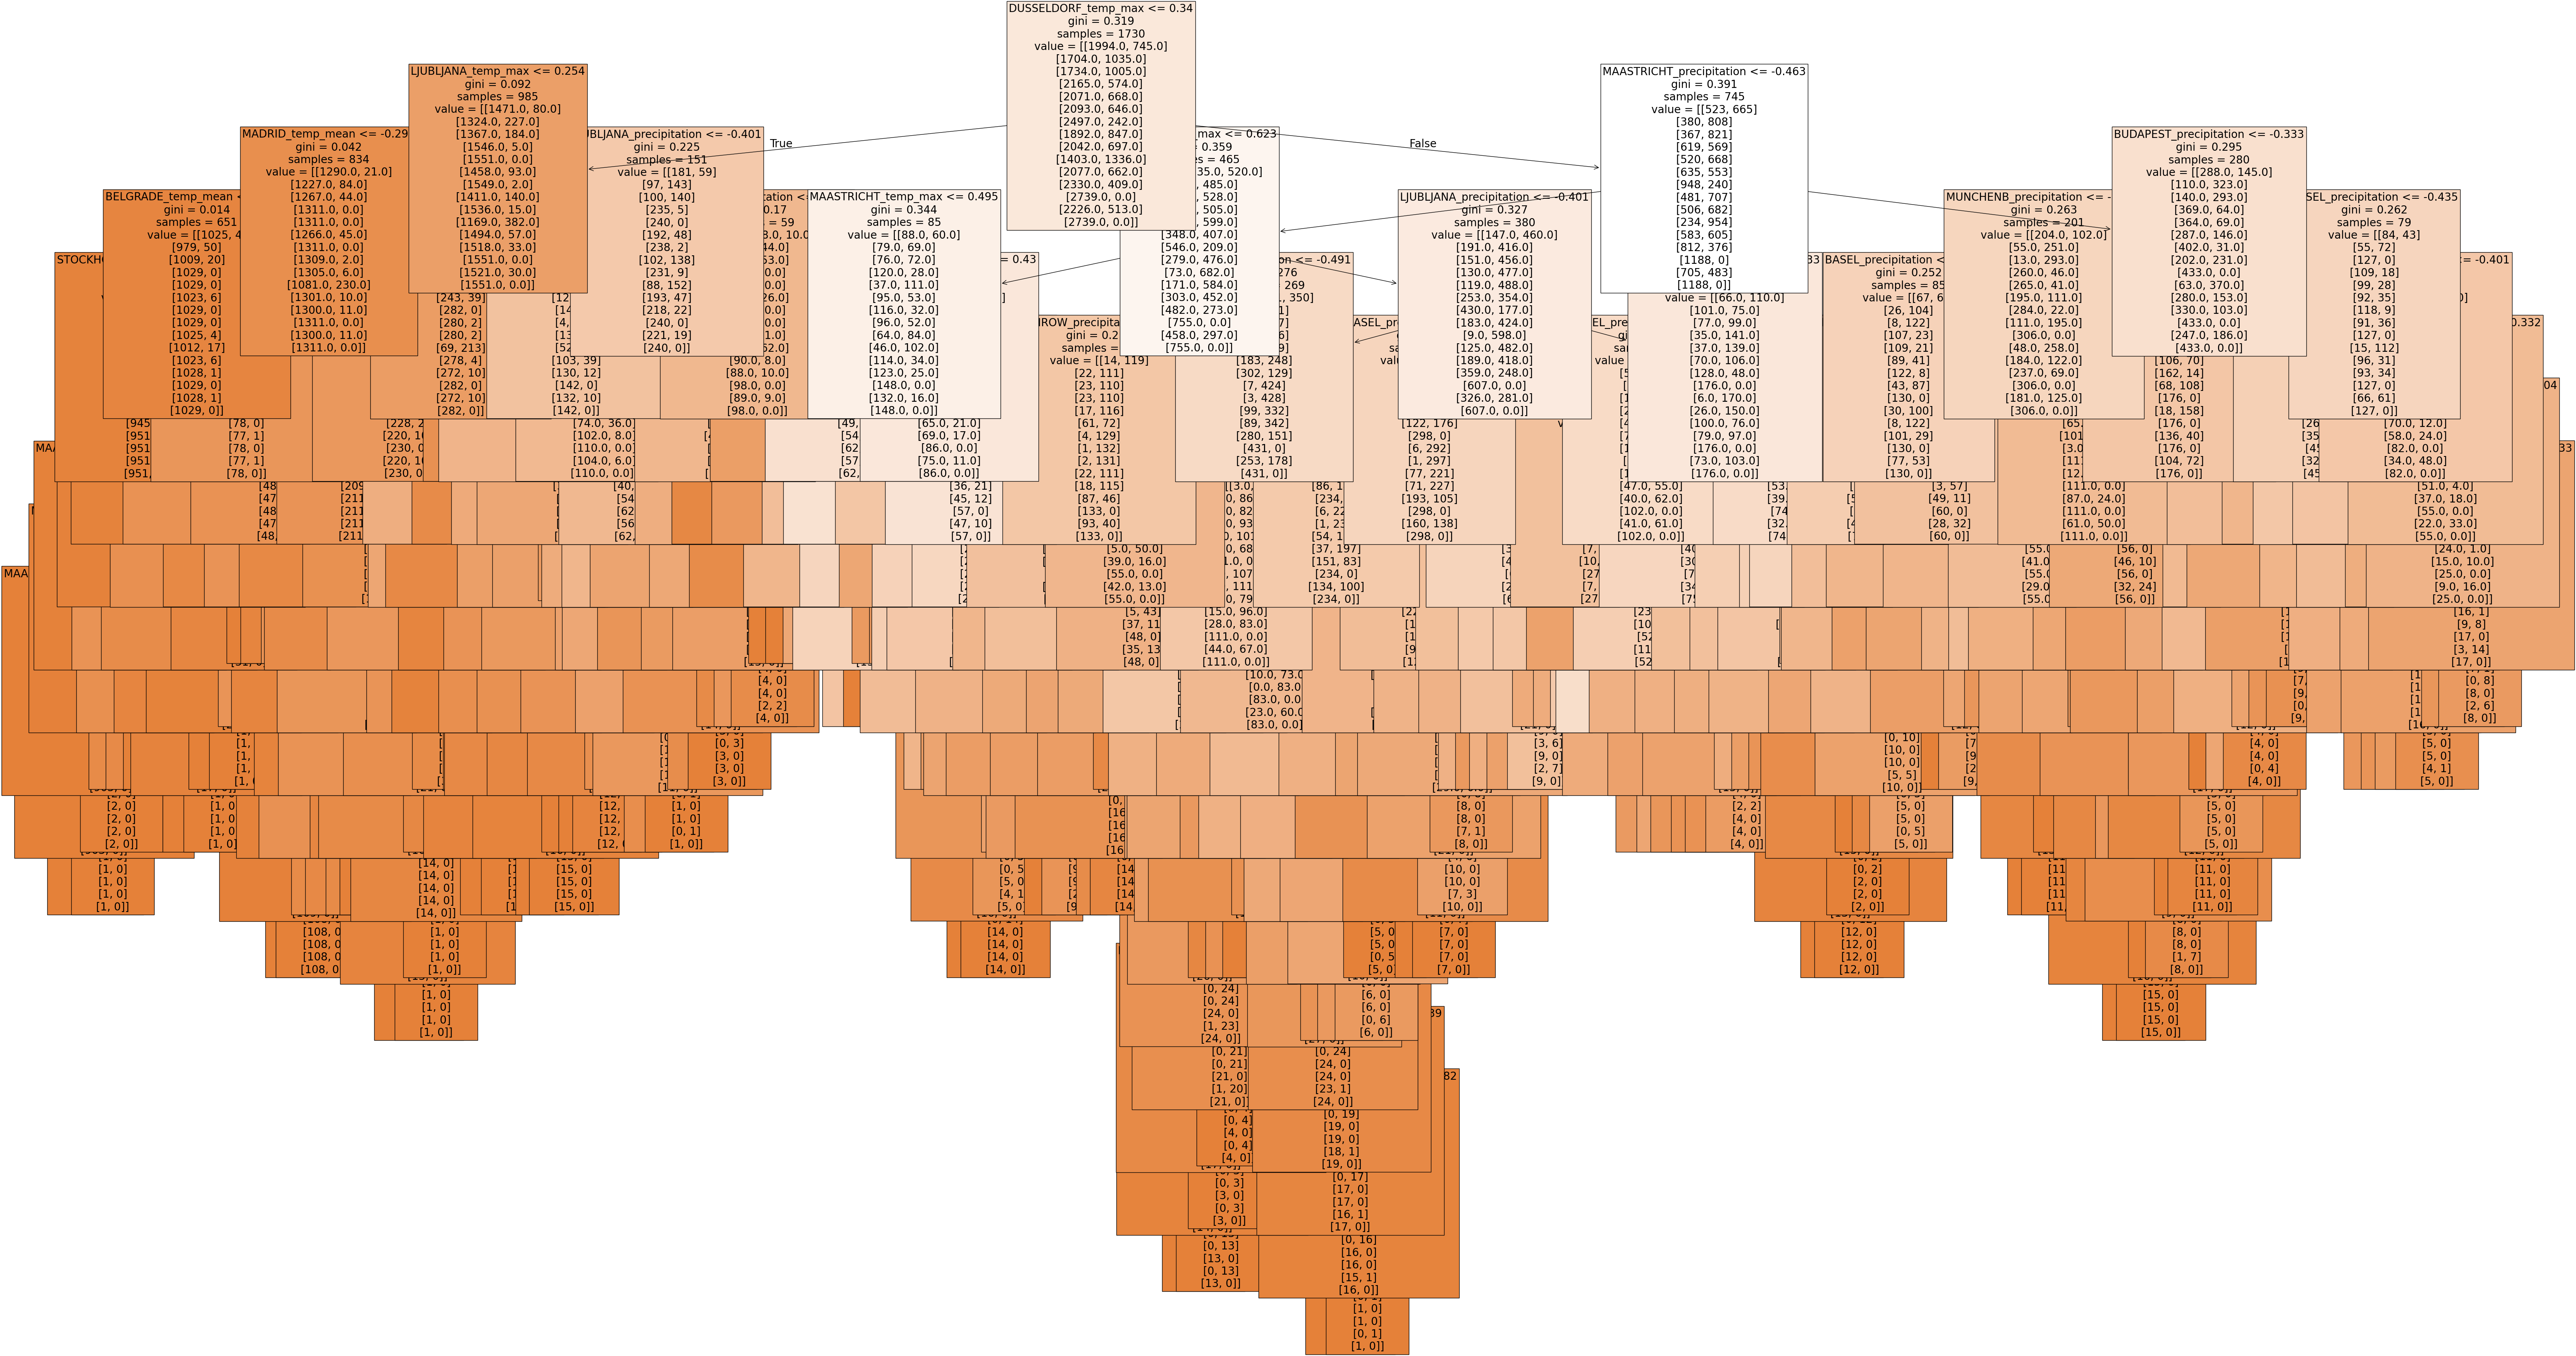

In [30]:
fig = plt.figure(figsize=(80,40))
plot_tree(clf3.estimators_[15], fontsize = 20, feature_names = dfdecade.columns, class_names=['unpleasant', 'pleasant'], filled=True);


In [31]:
plt.savefig(os.path.join(path, 'Visualizations', 'optimizes_2010s_random_forest.png'), bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [32]:
# Retrieve feature importances from the trained model

newarray = clf3.feature_importances_
print(clf3.feature_importances_.shape)
newarray

(135,)


array([6.92360227e-04, 1.38305677e-03, 1.12390076e-03, 1.06067420e-03,
       3.18197277e-02, 2.81744209e-03, 1.29921445e-03, 8.62208902e-04,
       9.00941443e-02, 2.06262860e-03, 1.28642340e-03, 1.24785354e-03,
       1.04104562e-03, 2.95859069e-02, 1.21675021e-03, 2.57121075e-03,
       8.24175780e-04, 7.75055528e-03, 1.38761168e-04, 0.00000000e+00,
       0.00000000e+00, 4.53367696e-04, 3.10286579e-02, 4.79155690e-04,
       4.88097677e-03, 8.36338094e-04, 2.41909919e-02, 7.20720509e-04,
       8.70153181e-04, 1.05306995e-03, 1.18947675e-03, 1.92181784e-02,
       1.32307780e-03, 1.27076175e-03, 1.03772920e-03, 2.93393338e-02,
       5.87301362e-04, 7.44047703e-04, 9.78240995e-04, 1.06933697e-03,
       4.02335100e-02, 1.19319119e-03, 4.68277225e-03, 8.65066088e-04,
       1.74290188e-01, 9.50424169e-04, 2.12350261e-03, 1.04836741e-03,
       2.28644847e-03, 1.61184291e-02, 2.64762714e-03, 2.09007521e-03,
       8.16201015e-04, 9.77372339e-03, 7.81201213e-04, 1.23305393e-03,
      

In [34]:
# Reshape newarray

newarray = newarray.reshape(-1,15,9)
print(newarray.shape)
newarray

(1, 15, 9)


array([[[6.92360227e-04, 1.38305677e-03, 1.12390076e-03, 1.06067420e-03,
         3.18197277e-02, 2.81744209e-03, 1.29921445e-03, 8.62208902e-04,
         9.00941443e-02],
        [2.06262860e-03, 1.28642340e-03, 1.24785354e-03, 1.04104562e-03,
         2.95859069e-02, 1.21675021e-03, 2.57121075e-03, 8.24175780e-04,
         7.75055528e-03],
        [1.38761168e-04, 0.00000000e+00, 0.00000000e+00, 4.53367696e-04,
         3.10286579e-02, 4.79155690e-04, 4.88097677e-03, 8.36338094e-04,
         2.41909919e-02],
        [7.20720509e-04, 8.70153181e-04, 1.05306995e-03, 1.18947675e-03,
         1.92181784e-02, 1.32307780e-03, 1.27076175e-03, 1.03772920e-03,
         2.93393338e-02],
        [5.87301362e-04, 7.44047703e-04, 9.78240995e-04, 1.06933697e-03,
         4.02335100e-02, 1.19319119e-03, 4.68277225e-03, 8.65066088e-04,
         1.74290188e-01],
        [9.50424169e-04, 2.12350261e-03, 1.04836741e-03, 2.28644847e-03,
         1.61184291e-02, 2.64762714e-03, 2.09007521e-03, 8.16201015

In [35]:
# Collapse this shape into one observation for each weather station

sumarray = np.sum(newarray[0], axis=1)
sumarray

array([0.13115273, 0.04758655, 0.06200825, 0.0560225 , 0.22464365,
       0.0378548 , 0.02329857, 0.07141455, 0.12867964, 0.07907705,
       0.06044084, 0.03812669, 0.00784258, 0.03038597, 0.00146561])

In [36]:
# Extract stations list

stations = [col.split('_')[0] for col in dfdecade.columns if '_' in col]

In [37]:
# Create a set of unique station names

unique_stations = set(stations)
unique_stations

{'BASEL',
 'BELGRADE',
 'BUDAPEST',
 'DEBILT',
 'DUSSELDORF',
 'HEATHROW',
 'KASSEL',
 'LJUBLJANA',
 'MAASTRICHT',
 'MADRID',
 'MUNCHENB',
 'OSLO',
 'SONNBLICK',
 'STOCKHOLM',
 'VALENTIA'}

In [40]:

important = pd.Series(sumarray, index = unique_stations)
important = important.sort_values(ascending = False)
important

VALENTIA      0.224644
STOCKHOLM     0.131153
MAASTRICHT    0.128680
BASEL         0.079077
MUNCHENB      0.071415
SONNBLICK     0.062008
KASSEL        0.060441
OSLO          0.056023
MADRID        0.047587
BELGRADE      0.038127
HEATHROW      0.037855
DEBILT        0.030386
LJUBLJANA     0.023299
DUSSELDORF    0.007843
BUDAPEST      0.001466
dtype: float64

In [42]:
# if unique_stations is a set, order it (sorted is stable/reproducible)
unique_stations_list = sorted(list(unique_stations))

# make sure lengths match
if len(unique_stations_list) != len(sumarray):
    raise ValueError(f"Length mismatch: {len(sumarray)} values vs {len(unique_stations_list)} labels")

df_importance = pd.DataFrame({
    "Weather Station": unique_stations_list,
    "Importance": np.asarray(sumarray, dtype=float)
}).sort_values("Importance", ascending=False)

['BASEL', 'BELGRADE', 'BUDAPEST', 'DEBILT', 'DUSSELDORF', 'HEATHROW', 'KASSEL', 'LJUBLJANA', 'MAASTRICHT', 'MADRID', 'MUNCHENB', 'OSLO', 'SONNBLICK', 'STOCKHOLM', 'VALENTIA']


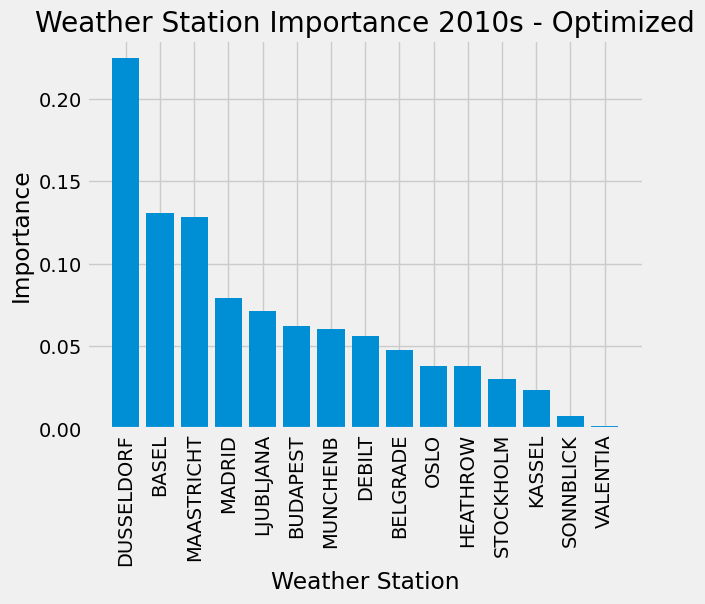

In [44]:
# Plot the results

%matplotlib inline

plt.style.use('fivethirtyeight')
print(unique_stations_list)

plt.bar(df_importance['Weather Station'], df_importance['Importance'], orientation = 'vertical')
plt.xticks(rotation='vertical')
plt.xlabel('Weather Station')
plt.ylabel('Importance')
plt.title('Weather Station Importance 2010s - Optimized')

plt.savefig(os.path.join(path,'Visualizations','optimized_2010s_feauture_importances.png'), bbox_inches='tight')

plt.show()